# [★ 도전문제] 사전학습된 ResNet 모델을 활용한 이미지 유사도 검색

- ResNet50 사전학습 모델로 강아지 이미지 20장의 임베딩 벡터 추출
- 입력 이미지(compare.jpeg)와 코사인 유사도 계산
- 가장 유사한 이미지 1장을 출력

## 1. 라이브러리 불러오기

In [27]:
import os
import torch
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
from torch.nn.functional import cosine_similarity

## 2. 사전학습된 ResNet50 모델 불러오기
- 마지막 분류층(fc)을 제거하여 2048차원 임베딩 추출 모델 구성

In [28]:
# ResNet50 사전학습 가중치 불러오기
weights = models.ResNet50_Weights.IMAGENET1K_V2
base_model = models.resnet50(weights=weights)

# 마지막 분류층 제거 → 임베딩 추출용 모델
embedding_model = torch.nn.Sequential(
    *list(base_model.children())[:-1],
    torch.nn.Flatten()
)

# 추론 모드로 설정 (Dropout, BatchNorm 고정)
embedding_model.eval()
print('모델 준비 완료')

모델 준비 완료


## 3. 이미지 전처리 정의
- ResNet50 입력 형식에 맞게 Resize, Tensor 변환, 정규화

In [29]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

## 4. 임베딩 추출 함수 정의

In [30]:
def get_embedding(img_path):
    # 이미지 로드 및 전처리
    img = Image.open(img_path).convert('RGB')
    x = preprocess(img).unsqueeze(0)  # 배치 차원 추가
    
    # 임베딩 벡터 추출
    with torch.no_grad():
        embedding = embedding_model(x)
    return embedding

## 5. 강아지 이미지 20장 임베딩 추출

In [31]:
# dogs 폴더에서 이미지 파일 목록 가져오기
dogs_dir = 'dogs'
dog_files = sorted([f for f in os.listdir(dogs_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

print(f'이미지 개수: {len(dog_files)}장')

# 각 이미지의 임베딩 벡터 저장
dog_embeddings = []
for file in dog_files:
    path = os.path.join(dogs_dir, file)
    emb = get_embedding(path)
    dog_embeddings.append(emb)

# 하나의 텐서로 합치기 (20, 2048)
dog_embeddings = torch.cat(dog_embeddings, dim=0)
print(f'임베딩 텐서 shape: {dog_embeddings.shape}')

이미지 개수: 20장
임베딩 텐서 shape: torch.Size([20, 2048])


## 6. 입력 이미지(compare.jpeg) 임베딩 추출

In [32]:
query_path = 'compare.jpeg'
query_embedding = get_embedding(query_path)
print(f'입력 이미지 임베딩 shape: {query_embedding.shape}')

입력 이미지 임베딩 shape: torch.Size([1, 2048])


## 7. 코사인 유사도 계산

In [33]:
# 입력 이미지 벡터 vs 20개 강아지 벡터
similarities = cosine_similarity(query_embedding, dog_embeddings)

# 유사도 결과 출력
print('강아지 이미지별 유사도:')
for file, sim in zip(dog_files, similarities):
    print(f'  {file}: {sim.item():.4f}')

강아지 이미지별 유사도:
  dog1.jpg: 0.1928
  dog10.jpg: 0.2649
  dog11.jpg: 0.0777
  dog12.jpg: 0.2378
  dog13.jpeg: 0.2058
  dog14.jpg: 0.8634
  dog15.jpg: 0.1479
  dog16.jpeg: 0.7296
  dog17.jpg: 0.7713
  dog18.jpg: 0.2180
  dog19.jpg: 0.2655
  dog2.jpg: 0.0915
  dog20.jpg: 0.0948
  dog3.jpg: 0.1036
  dog4.jpg: 0.3103
  dog5.jpg: 0.1244
  dog6.jpg: 0.2400
  dog7.jpg: 0.1489
  dog8.jpg: 0.1875
  dog9.jpg: 0.1450


## 8. 가장 유사한 이미지 찾기

In [34]:
# 유사도가 가장 높은 이미지 선택
best_idx = similarities.argmax().item()
best_file = dog_files[best_idx]
best_score = similarities[best_idx].item()

print(f'가장 유사한 이미지: {best_file}')
print(f'코사인 유사도: {best_score:.4f}')

가장 유사한 이미지: dog14.jpg
코사인 유사도: 0.8634


## 9. 결과 시각화
- 입력 이미지와 가장 유사한 이미지를 나란히 출력

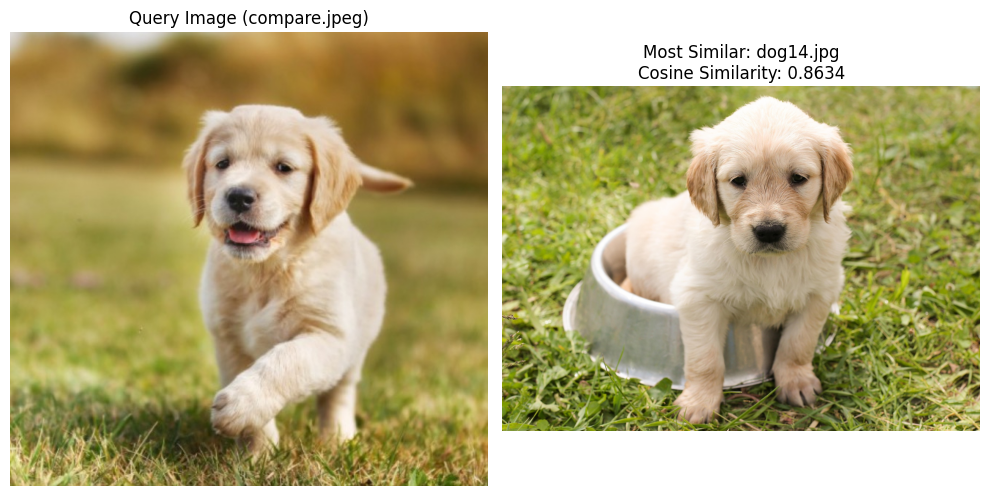

In [35]:
query_img = Image.open(query_path).convert('RGB')
best_img = Image.open(os.path.join(dogs_dir, best_file)).convert('RGB')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(query_img)
axes[0].set_title('Query Image (compare.jpeg)')
axes[0].axis('off')

axes[1].imshow(best_img)
axes[1].set_title(f'Most Similar: {best_file}\nCosine Similarity: {best_score:.4f}')
axes[1].axis('off')

plt.tight_layout()
plt.show()